<a href="https://colab.research.google.com/github/robyperez/IA/blob/dev/Copia_de_Taller_precio_del_caf%C3%A9_Regresi%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error

**Carga de datos**

In [ ]:
# Cargar archivo Excel
file_path = "/content/Precios-area-y-produccion-de-cafe-2025.xlsx"
df = pd.ExcelFile(file_path)

# Leer la hoja específica
df_cafe = df.parse("2. Precio Interno Mensual", skiprows=5)

# Seleccionar solo las columnas de interés
df_cafe = df_cafe.iloc[:, [3, 4]]  # Columnas D y E (Fecha y Precio)
df_cafe.columns = ["Fecha", "Precio"]
df_cafe.dropna(inplace=True)  # Eliminar filas vacías

# Convertir la columna de fecha a formato datetime
df_cafe["Fecha"] = pd.to_datetime(df_cafe["Fecha"])

# Mostrar las primeras filas
df_cafe.head()


,Fecha,Precio
0,1944-01-01,44.0
1,1944-02-01,44.0
2,1944-03-01,47.0
3,1944-04-01,47.0
4,1944-05-01,47.0


**Ingenieria de datos**

In [ ]:
df_cafe["Año"] = df_cafe["Fecha"].dt.year
df_cafe["Mes"] = df_cafe["Fecha"].dt.month
df_cafe["Día_del_año"] = df_cafe["Fecha"].dt.dayofyear
df_cafe["Trimestre"] = df_cafe["Fecha"].dt.quarter

# Eliminar la columna de fecha (ya no es útil)
df_cafe = df_cafe.drop(columns=["Fecha"])

# Mostrar datos procesados
df_cafe.head()


,Precio,Año,Mes,Día_del_año,Trimestre
0,44.0,1944,1,1,1
1,44.0,1944,2,32,1
2,47.0,1944,3,61,1
3,47.0,1944,4,92,2
4,47.0,1944,5,122,2


**Normalización de datos**

In [ ]:
scaler = MinMaxScaler()
df_cafe_scaled = pd.DataFrame(scaler.fit_transform(df_cafe), columns=df_cafe.columns)

# Mostrar los datos normalizados
df_cafe_scaled.head()


,Precio,Año,Mes,Día_del_año,Trimestre
0,0.000000e+00,0.0,0.000000,0.000000,0.000000
1,0.000000e+00,0.0,0.090909,0.092537,0.000000
2,9.619925e-07,0.0,0.181818,0.179104,0.000000
3,9.619925e-07,0.0,0.272727,0.271642,0.333333
4,9.619925e-07,0.0,0.363636,0.361194,0.333333


**Dividir los datos en entrenamiento y prueba**

In [ ]:
# Variables predictoras (X) y variable objetivo (y)
X = df_cafe_scaled.drop(columns=["Precio"])
y = df_cafe_scaled["Precio"]

# Dividir en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Mostrar tamaños de los conjuntos
print(f"Tamaño del conjunto de entrenamiento: {X_train.shape}")
print(f"Tamaño del conjunto de prueba: {X_test.shape}")


Tamaño del conjunto de entrenamiento: (682, 4)
Tamaño del conjunto de prueba: (293, 4)


**Construir y entrenar el modelo de regresión**

In [ ]:
# Definir el modelo de red neuronal para regresión
modelo = MLPRegressor(
    solver='adam',
    activation='relu',
    alpha=0.0001,
    tol=1e-10,
    hidden_layer_sizes=(5,3,1),
    learning_rate='constant',
    learning_rate_init=0.01,
    max_iter=500,
    momentum=0.9,
    verbose=True
)

# Entrenar el modelo
modelo.fit(X_train, y_train)


Iteration 1, loss = 1.06740793
Iteration 2, loss = 1.01017269
Iteration 3, loss = 0.95456759
Iteration 4, loss = 0.90100601
Iteration 5, loss = 0.84915390
Iteration 6, loss = 0.79947981
Iteration 7, loss = 0.75171796
Iteration 8, loss = 0.70592545
Iteration 9, loss = 0.66232986
Iteration 10, loss = 0.62058686
Iteration 11, loss = 0.58097123
Iteration 12, loss = 0.54315348
Iteration 13, loss = 0.50734699
Iteration 14, loss = 0.47332209
Iteration 15, loss = 0.44121447
Iteration 16, loss = 0.41081227
Iteration 17, loss = 0.38212309
Iteration 18, loss = 0.35500676
Iteration 19, loss = 0.32959069
Iteration 20, loss = 0.30560082
Iteration 21, loss = 0.28309957
Iteration 22, loss = 0.26197197
Iteration 23, loss = 0.24227184
Iteration 24, loss = 0.22374370
Iteration 25, loss = 0.20643034
Iteration 26, loss = 0.19032766
Iteration 27, loss = 0.17536690
Iteration 28, loss = 0.16142177
Iteration 29, loss = 0.14847926
Iteration 30, loss = 0.13647825
Iteration 31, loss = 0.12536065
Iteration 32, los

MLPRegressor(hidden_layer_sizes=(5, 3, 1), learning_rate_init=0.01,
             max_iter=500, tol=1e-10, verbose=True)

**Evaluación del modelo**

In [ ]:
# Predicciones en el conjunto de prueba
y_pred = modelo.predict(X_test)

# Evaluar el desempeño del modelo
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2}")
print(f"Error cuadrático medio (MSE): {mse}")


R² Score: -0.0017528601270968558
Error cuadrático medio (MSE): 0.028723342970093064


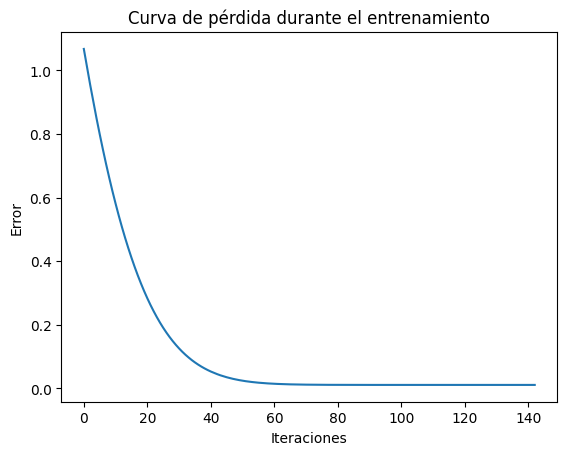

In [ ]:
plt.plot(modelo.loss_curve_)
plt.xlabel("Iteraciones")
plt.ylabel("Error")
plt.title("Curva de pérdida durante el entrenamiento")
plt.show()


**Comparación entre valores reales y predichos**

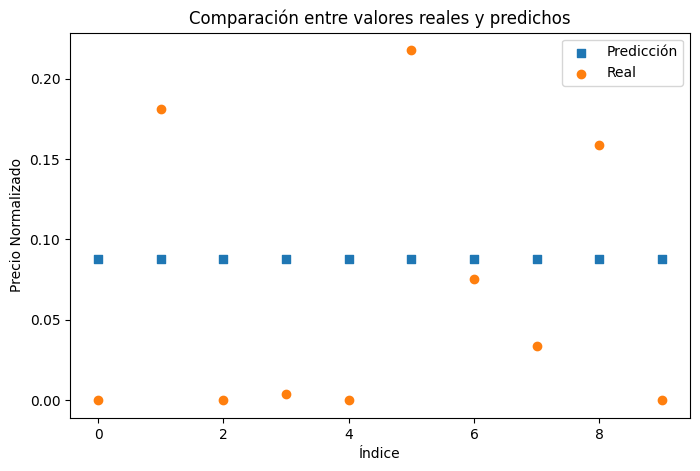

In [ ]:
# Seleccionar 10 valores para visualizar
muestra_X = X_test[:10]
muestra_y_real = y_test[:10]

# Predicciones
muestra_y_pred = modelo.predict(muestra_X)

# Gráfica de comparación
plt.figure(figsize=(8,5))
plt.scatter(range(len(muestra_y_pred)), muestra_y_pred, marker="s", label="Predicción")
plt.scatter(range(len(muestra_y_real)), muestra_y_real, marker="o", label="Real")
plt.xlabel("Índice")
plt.ylabel("Precio Normalizado")
plt.legend()
plt.title("Comparación entre valores reales y predichos")
plt.show()


**Hacer una predicción con datos nuevos**

In [ ]:
# Suponiendo que queremos predecir para enero de 2026
# Agregar un valor para 'Precio' (puede ser 0 o un valor estimado)
nuevo_dato = np.array([[2026, 1, 1, 1, 0]])  # Año, mes, día del año, trimestre, Precio
nuevo_dato = scaler.transform(nuevo_dato)  # Normalizar

# Hacer la predicción
prediccion = modelo.predict(nuevo_dato[:, :-1]) # Seleccionar todas las columnas excepto la última (Precio)
prediccion_real = prediccion * df_cafe["Precio"].max()  # Desnormalizar

print(f"Predicción del precio del café en enero de 2026: {prediccion_real[0]:.2f}")

Predicción del precio del café en enero de 2026: 274383.23


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(
